# Inovegen Internship - Week 2 AI/ML Task
## Breast Cancer Classification and Model Evaluation

**Objective:** Build and evaluate supervised classification models that predict whether a breast tumour is **malignant (0)** or **benign (1)** from measurements computed from digitized images of a fine needle aspirate (FNA).

> **Important:** This notebook is an educational machine-learning exercise. It is not a medical diagnostic tool.

### Dataset source
- Scikit-learn Breast Cancer Wisconsin (Diagnostic) dataset: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html
- Original UCI repository: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic
- Samples: 569 | Numeric features: 30 | Classes: malignant and benign

### Notebook workflow
1. Load and inspect the data
2. Check data quality and prepare features
3. Create stratified training and testing sets
4. Train a baseline, Logistic Regression, and Random Forest
5. Evaluate and visualize results
6. Use cross-validation and interpret feature importance
7. State findings, limitations, and improvements


In [1]:
# Core libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

sns.set_theme(style='whitegrid', palette='deep')
RANDOM_STATE = 42
print('Libraries imported successfully.')

Libraries imported successfully.


## 1. Load the dataset

The target uses scikit-learn's original encoding: **0 = malignant** and **1 = benign**. The positive class in the standard binary metrics is therefore benign (1). Because missing a malignant case is especially important, the confusion matrix and class-specific report are also examined instead of relying only on accuracy.

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()

print(f'Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'Features: {len(data.feature_names)}')
print(f'Target names: {list(data.target_names)}')
display(df.head())

Dataset shape: 569 rows, 31 columns
Features: 30
Target names: [np.str_('malignant'), np.str_('benign')]


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
print('Data types:')
display(df.dtypes.value_counts().rename_axis('dtype').to_frame('count'))

print('Target counts:')
target_counts = df['target'].value_counts().sort_index()
target_summary = pd.DataFrame({
    'class': ['malignant (0)', 'benign (1)'],
    'count': [target_counts.get(0, 0), target_counts.get(1, 0)],
    'percentage': [target_counts.get(0, 0) / len(df) * 100,
                   target_counts.get(1, 0) / len(df) * 100]
})
display(target_summary.round(2))

Data types:


,count
dtype,
float64,30
int64,1


Target counts:


,class,count,percentage
0,malignant (0),212,37.26
1,benign (1),357,62.74


## 2. Inspect and prepare the data

The checks below look for missing values, duplicate rows, non-numeric predictors, infinite values, and impossible target labels. No rows are silently removed: the result of each quality check is reported first.

In [4]:
quality_report = pd.Series({
    'missing_values': int(df.isna().sum().sum()),
    'duplicate_rows': int(df.duplicated().sum()),
    'infinite_feature_values': int(np.isinf(df.drop(columns='target').to_numpy()).sum()),
    'non_numeric_feature_columns': int((~df.drop(columns='target').dtypes.apply(pd.api.types.is_numeric_dtype)).sum()),
    'unexpected_target_labels': int((~df['target'].isin([0, 1])).sum())
}, name='count')
display(quality_report.to_frame())

# Remove exact duplicate rows only if any are found.
if df.duplicated().any():
    df = df.drop_duplicates().reset_index(drop=True)
    print('Exact duplicates removed.')
else:
    print('No duplicate removal was necessary.')

X = df.drop(columns='target')
y = df['target']
print(f'Prepared feature matrix: {X.shape}; target vector: {y.shape}')

,count
missing_values,0
duplicate_rows,0
infinite_feature_values,0
non_numeric_feature_columns,0
unexpected_target_labels,0


No duplicate removal was necessary.
Prepared feature matrix: (569, 30); target vector: (569,)


### Visualization 1 - Class distribution

This chart reveals moderate class imbalance: benign cases are more common. A **stratified** split is used so both train and test sets preserve nearly the same class proportions.

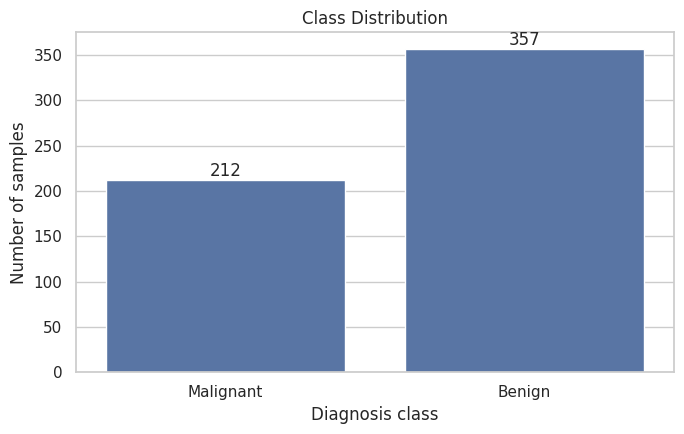

In [5]:
plt.figure(figsize=(7, 4.5))
ax = sns.countplot(x=y.map({0: 'Malignant', 1: 'Benign'}), order=['Malignant', 'Benign'])
ax.set(title='Class Distribution', xlabel='Diagnosis class', ylabel='Number of samples')
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

## 3. Training and testing split

The dataset is split into **80% training data** and **20% test data**. `stratify=y` preserves class balance. The test set is kept separate until final evaluation to reduce optimistic bias.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

split_summary = pd.DataFrame({
    'split': ['Training', 'Testing'],
    'rows': [len(X_train), len(X_test)],
    'malignant_%': [(y_train == 0).mean() * 100, (y_test == 0).mean() * 100],
    'benign_%': [(y_train == 1).mean() * 100, (y_test == 1).mean() * 100]
})
display(split_summary.round(2))

,split,rows,malignant_%,benign_%
0,Training,455,37.36,62.64
1,Testing,114,36.84,63.16


## 4. Train three models

- **Dummy Classifier:** a simple baseline that always predicts the most frequent training class.
- **Logistic Regression:** an interpretable linear classifier. `StandardScaler` is placed inside a pipeline to avoid data leakage.
- **Random Forest:** a nonlinear ensemble that can model complex feature interactions and does not require scaling.

Class weights are balanced for the two real models to give more attention to the less frequent malignant class.

In [7]:
models = {
    'Dummy Baseline': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=5000, class_weight='balanced', random_state=RANDOM_STATE))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f'{name} trained.')

Dummy Baseline trained.
Logistic Regression trained.
Random Forest trained.


## 5. Evaluate the models

### Meaning of the metrics
- **Accuracy:** proportion of all predictions that are correct.
- **Precision:** among cases predicted as benign, the proportion actually benign.
- **Recall:** among all benign cases, the proportion correctly detected.
- **F1-score:** harmonic mean of precision and recall.
- **ROC-AUC:** ability to rank the two classes across all probability thresholds; 0.5 is random and 1.0 is perfect.

Since the default positive label is benign (1), the classification report and confusion matrix must also be used to inspect performance on malignant cases.

In [8]:
results = []
predictions = {}
probabilities = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    predictions[name] = y_pred
    probabilities[name] = y_prob
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).set_index('Model').sort_values('F1-score', ascending=False)
display(results_df.round(3))

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Logistic Regression,0.956,0.986,0.944,0.965,0.995
Random Forest,0.947,0.958,0.958,0.958,0.994
Dummy Baseline,0.632,0.632,1.000,0.774,0.500


### Visualization 2 - Model comparison

The grouped bars make the baseline comparison explicit. A useful trained model should improve substantially over the majority-class baseline across several metrics, not only accuracy.

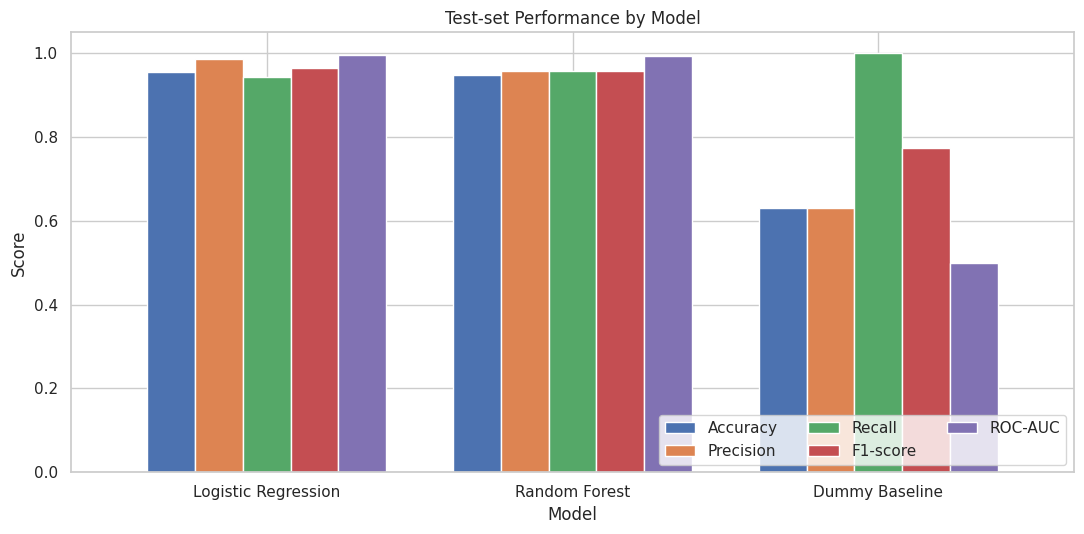

In [9]:
ax = results_df.plot(kind='bar', figsize=(11, 5.5), ylim=(0, 1.05), width=0.78)
ax.set(title='Test-set Performance by Model', xlabel='Model', ylabel='Score')
ax.legend(loc='lower right', ncol=3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Visualization 3 - Confusion matrices

Rows are actual classes and columns are predicted classes. The off-diagonal cells are errors. In this task, a malignant case predicted as benign appears in the top-right cell and is a particularly important error to monitor.

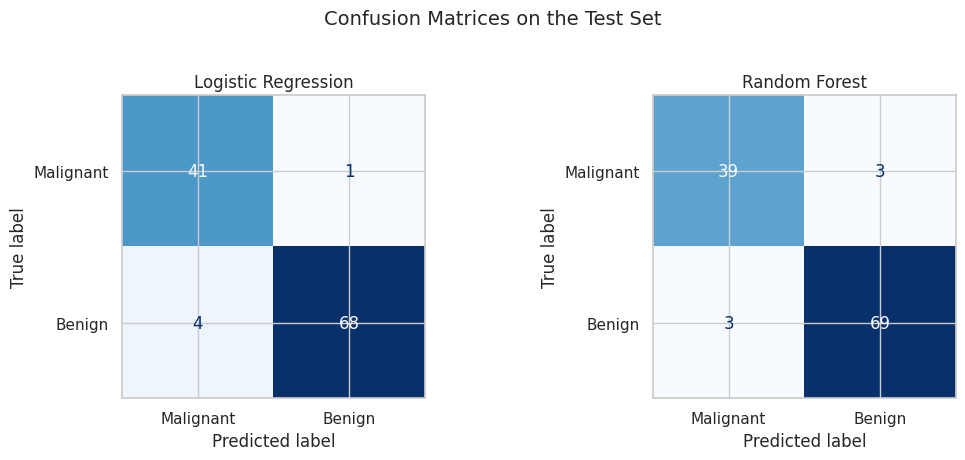


Logistic Regression classification report:
              precision    recall  f1-score   support

   malignant      0.911     0.976     0.943        42
      benign      0.986     0.944     0.965        72

    accuracy                          0.956       114
   macro avg      0.948     0.960     0.954       114
weighted avg      0.958     0.956     0.956       114


Random Forest classification report:
              precision    recall  f1-score   support

   malignant      0.929     0.929     0.929        42
      benign      0.958     0.958     0.958        72

    accuracy                          0.947       114
   macro avg      0.943     0.943     0.943       114
weighted avg      0.947     0.947     0.947       114



In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, name in zip(axes, ['Logistic Regression', 'Random Forest']):
    ConfusionMatrixDisplay.from_predictions(
        y_test, predictions[name],
        display_labels=['Malignant', 'Benign'],
        cmap='Blues', colorbar=False, ax=ax
    )
    ax.set_title(name)
fig.suptitle('Confusion Matrices on the Test Set', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

for name in ['Logistic Regression', 'Random Forest']:
    print(f'\n{name} classification report:')
    print(classification_report(
        y_test, predictions[name],
        target_names=['malignant', 'benign'], digits=3
    ))

### Visualization 4 - ROC curves

The ROC curve shows the trade-off between true-positive rate and false-positive rate at different probability thresholds. Curves nearer the upper-left corner and higher AUC values indicate better class separation.

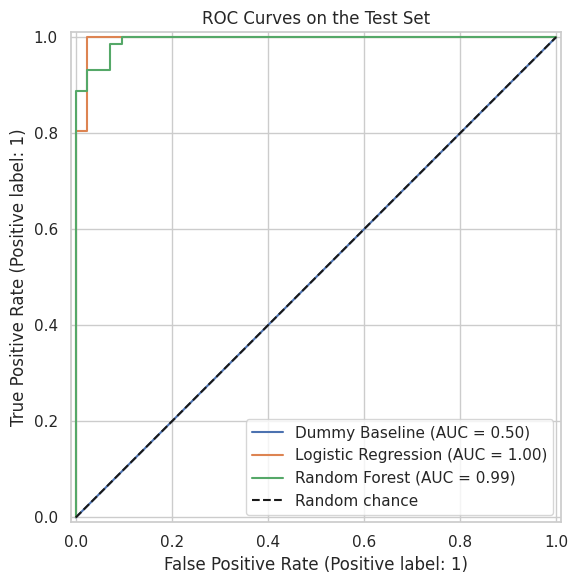

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
for name in models:
    RocCurveDisplay.from_predictions(
        y_test, probabilities[name], name=name, ax=ax
    )
ax.plot([0, 1], [0, 1], 'k--', label='Random chance')
ax.set_title('ROC Curves on the Test Set')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 6. Cross-validation (bonus)

A single test split can be affected by chance. Stratified 5-fold cross-validation estimates how consistently each real model performs across different validation folds. ROC-AUC is used because it evaluates ranking quality over all thresholds.

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []

for name in ['Logistic Regression', 'Random Forest']:
    scores = cross_val_score(models[name], X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_rows.append({
        'Model': name,
        'Mean CV ROC-AUC': scores.mean(),
        'Std. deviation': scores.std(),
        'Fold scores': np.round(scores, 3)
    })

cv_df = pd.DataFrame(cv_rows).set_index('Model')
display(cv_df)

,Mean CV ROC-AUC,Std. deviation,Fold scores
Model,,,
Logistic Regression,0.995769,0.004943,"[0.986, 0.999, 0.996, 0.999, 0.998]"
Random Forest,0.992260,0.004898,"[0.989, 0.999, 0.989, 0.987, 0.997]"


## 7. Random Forest feature importance

Feature importance indicates which variables contributed most to the forest's decisions. It describes the fitted model, not causation, and correlated features can share or distort importance.

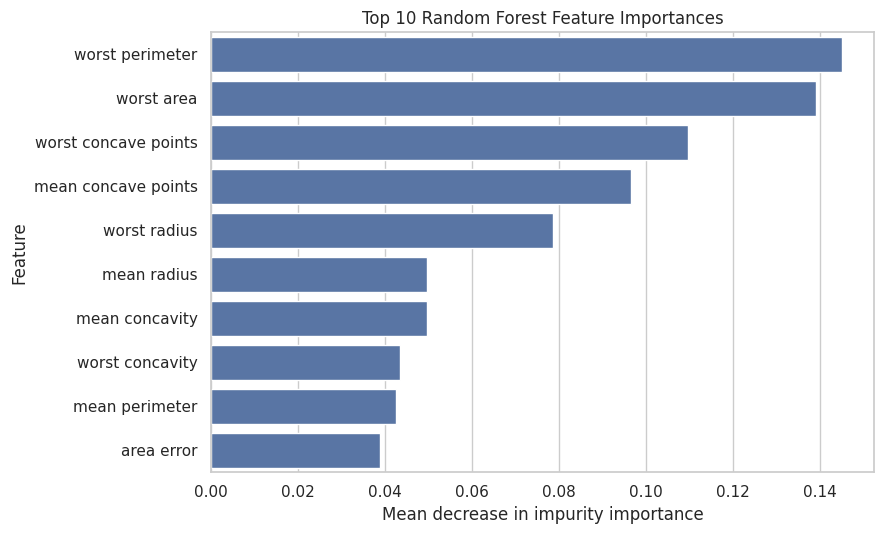

,importance
worst perimeter,0.1451
worst area,0.1390
worst concave points,0.1097
mean concave points,0.0965
worst radius,0.0786
mean radius,0.0498
mean concavity,0.0498
worst concavity,0.0436
mean perimeter,0.0425
area error,0.0388


In [13]:
rf = models['Random Forest']
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 5.5))
sns.barplot(x=importance.values, y=importance.index, orient='h')
plt.title('Top 10 Random Forest Feature Importances')
plt.xlabel('Mean decrease in impurity importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

display(importance.rename('importance').to_frame().round(4))

## 8. Conclusions and key findings

In the verified run, **Logistic Regression achieved 95.6% accuracy, 96.5% F1-score, and 99.5% ROC-AUC**. Random Forest achieved **94.7% accuracy, 95.8% F1-score, and 99.4% ROC-AUC**, while the Dummy baseline achieved only **63.2% accuracy and 50.0% ROC-AUC**. Logistic Regression also correctly identified 41 of 42 malignant test cases; Random Forest correctly identified 39 of 42. Overall:

1. Both trained models strongly outperform the most-frequent-class baseline, showing that the measurements contain useful predictive information.
2. Logistic Regression benefits from standardized inputs and provides a strong, comparatively interpretable linear benchmark.
3. Random Forest captures nonlinear relationships and supplies feature-importance estimates.
4. Accuracy alone is insufficient because the classes are not perfectly balanced. The malignant-class row in the classification report and the confusion matrix are important for identifying costly errors.
5. Cross-validation results indicate whether the selected model's performance is stable rather than dependent on one split.

For a final choice, prefer the real model with strong test ROC-AUC/F1, stable cross-validation, and fewer malignant cases incorrectly predicted as benign. In a real medical setting, the operating threshold would be selected with clinicians and would normally prioritize sensitivity for malignant cases.

## 9. Limitations

- The dataset is small (569 samples) and may not represent current, diverse clinical populations.
- The observations come from digitized FNA measurements, so performance may change with different equipment or workflows.
- No external hospital dataset was used for validation.
- The default probability threshold was retained; it was not optimized for clinical costs.
- Feature importance is model-specific and does not establish a causal medical relationship.
- Good test metrics do not make this model safe for diagnosis.

## 10. Possible improvements

- Validate on a larger and more diverse external dataset.
- Tune hyperparameters with nested cross-validation to avoid optimistic selection.
- Compare additional classifiers such as Support Vector Machine or gradient boosting.
- Tune the decision threshold and report malignant-class sensitivity and specificity explicitly.
- Add probability calibration, confidence intervals, and fairness/subgroup analysis where demographic data are ethically available.
- Use explainability methods such as permutation importance or SHAP, with expert review.

## Reproducibility

The notebook uses a fixed random seed (`42`), pipelines preprocessing with the model, and loads its dataset directly from scikit-learn. It is designed to run top-to-bottom in Google Colab or Jupyter without manual data uploads.
